## 1. Hiểu bài toán kinh doanh (Business Understanding)
**Bài toán kinh doanh**
- Doanh nghiệp hiện chưa có các nhóm khách hàng rõ ràng để phục vụ marketing mục tiêu.
- Cần phân tích hành vi khách hàng để nhận diện các mô hình tiêu dùng trước khi xây dựng mô hình phân nhóm.

**Mục tiêu dự án**
- Phân tích hành vi của khách hàng, doanh thu, phương thức thanh toán và sản phẩm.
- Xây dựng bộ dữ liệu sạch ở cấp độ khách hàng để phục vụ cho việc phân tích RFM và phân cụm bằng KMeans.

**Câu hỏi quan trọng** 
- Doanh thu đến từ đâu?
- Khách hàng có quay lại không?
- Khách chi bao nhiêu?
- Họ mua gì?
- Thanh toán như nào?

**Các KPI dự kiến**
- Tổng doanh thu (Total Revenue)
- Tổng số đơn hàng (Total Orders)
- Tổng số khách hàng (Total Customers)
- Giá trị đơn hàng trung bình (Average Order Value)
- Điểm đánh giá trung bình (Average Review Score)
- Tỷ lệ khách hàng quay lại (Repeat Rate)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


In [2]:
base = Path(".")

customers = pd.read_csv(base / "olist_customers_dataset.csv")
orders = pd.read_csv(
    base / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
order_items = pd.read_csv(base / "olist_order_items_dataset.csv")
payments = pd.read_csv(base / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(
    base / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
products = pd.read_csv(base / "olist_products_dataset.csv")
translation = pd.read_csv(base / "product_category_name_translation.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "translation": translation,
}


## 2. Dataset Overview



In [3]:
for name, df in datasets.items():
    print(f"\n{name.upper()} - shape: {df.shape}")
    display(df.head(10))



CUSTOMERS - shape: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG



ORDERS - shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23



ORDER_ITEMS - shape: (112650, 7)


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47



PRODUCTS - shape: (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.00,745.00,1.00,200.00,38.00,5.00,11.00
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.00,"1,272.00",4.00,"18,350.00",70.00,24.00,44.00
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.00,184.00,2.00,900.00,40.00,8.00,40.00
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.00,163.00,1.00,400.00,27.00,13.00,17.00
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.00,"1,156.00",1.00,600.00,17.00,10.00,12.00



TRANSLATION - shape: (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()} - info")
    print(df.info())



CUSTOMERS - info
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

ORDERS - info
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purch

In [5]:
missing_summary = (
    pd.DataFrame({name: df.isna().sum() for name, df in datasets.items()})
    .fillna(0)
    .astype(int)
)
display(missing_summary)

key_checks = pd.DataFrame(
    {
        "metric": [
            "customers.customer_id unique",
            "customers.customer_unique_id unique",
            "orders.order_id unique",
            "order_items.order_id unique",
            "payments.order_id unique",
            "reviews.order_id unique",
        ],
        "value": [
            customers["customer_id"].nunique(),
            customers["customer_unique_id"].nunique(),
            orders["order_id"].nunique(),
            order_items["order_id"].nunique(),
            payments["order_id"].nunique(),
            reviews["order_id"].nunique(),
        ],
    }
)
display(key_checks)


,customers,orders,order_items,payments,reviews,products,translation
customer_city,0,0,0,0,0,0,0
customer_id,0,0,0,0,0,0,0
customer_state,0,0,0,0,0,0,0
customer_unique_id,0,0,0,0,0,0,0
customer_zip_code_prefix,0,0,0,0,0,0,0
freight_value,0,0,0,0,0,0,0
order_approved_at,0,160,0,0,0,0,0
order_delivered_carrier_date,0,1783,0,0,0,0,0
order_delivered_customer_date,0,2965,0,0,0,0,0
order_estimated_delivery_date,0,0,0,0,0,0,0


,metric,value
0,customers.customer_id unique,99441
1,customers.customer_unique_id unique,96096
2,orders.order_id unique,99441
3,order_items.order_id unique,98666
4,payments.order_id unique,99440
5,reviews.order_id unique,98673


## 3. Data Model và Grain

**Relationship notes**
- `customers.customer_id -> orders.customer_id`
- `orders.order_id -> order_items.order_id`
- `orders.order_id -> payments.order_id`
- `orders.order_id -> reviews.order_id`

**Quy tắc grain**
- `df_orders`: mỗi dòng `order_id`, dùng cho revenue KPI, monthly trend, state analysis, review analysis, và repeat customer analysis.
- `df_items`: mỗi dòng tương ứng 1 sản phẩm đơn hàng, dùng cho phân tích sản phẩm và danh mục
- `payment_value` phải giữ ở cấp độ đơn hàng (order-level) để tránh bị trùng (double counting)
- Doanh thu theo danh mục nên dùng giá trị ở cấp item: `price + freight_value`.
- ID Khách hàng thực sự là `customer_unique_id`, not `customer_id`.


In [6]:
#chỉ giữ đơn delivered
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

#gộp dữ liệu thanh toán theo order_id
payments_agg = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "mean"),
    )
)

#gộp review theo order_id
reviews_agg = (
    reviews.groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

#join bảng products với translation để có tên tiếng Anh để dễ đọc
products_en = products.merge(
    translation,
    on="product_category_name",
    how="left",
)


In [7]:
payments_agg.head()


,order_id,payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2.00
1,00018f77f2f0320c557190d7a144bdd3,259.83,3.00
2,000229ec398224ef6ca0657da4fc703e,216.87,5.00
3,00024acbcdf0a6daa1e931b038114c75,25.78,2.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3.00


In [8]:
reviews_agg.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.00
1,00018f77f2f0320c557190d7a144bdd3,4.00
2,000229ec398224ef6ca0657da4fc703e,5.00
3,00024acbcdf0a6daa1e931b038114c75,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00


In [9]:
products_en.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00,housewares


In [10]:
#join DL orders_delivered với customers, payments_agg, reviews_agg để có bảng tổng hợp thông tin đơn hàng
# df_orders = 1 row = 1 order
df_orders = (
    orders_delivered
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id",
                "customer_city",
                "customer_state",
                "customer_zip_code_prefix",
            ]
        ],
        on="customer_id",
        how="left",
    )
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

df_orders["payment_value"] = df_orders["payment_value"].fillna(0)
df_orders["order_month"] = df_orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
df_orders["order_year"] = df_orders["order_purchase_timestamp"].dt.year
df_orders["order_quarter"] = df_orders["order_purchase_timestamp"].dt.to_period("Q").astype(str)

display(df_orders.head())
#bảng df_orders dùng cho phân tích sau này

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,payment_value,payment_installments,review_score,order_month,order_year,order_quarter
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,3149,38.71,1.00,4.00,2017-10,2017,2017Q4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,47813,141.46,1.00,4.00,2018-07,2018,2018Q3
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,75265,179.12,3.00,5.00,2018-08,2018,2018Q3
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,59296,72.20,1.00,5.00,2017-11,2017,2017Q4
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,9195,28.62,1.00,5.00,2018-02,2018,2018Q1


In [11]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  str           
 1   customer_id                    96478 non-null  str           
 2   order_status                   96478 non-null  str           
 3   order_purchase_timestamp       96478 non-null  datetime64[us]
 4   order_approved_at              96464 non-null  datetime64[us]
 5   order_delivered_carrier_date   96476 non-null  datetime64[us]
 6   order_delivered_customer_date  96470 non-null  datetime64[us]
 7   order_estimated_delivery_date  96478 non-null  datetime64[us]
 8   customer_unique_id             96478 non-null  str           
 9   customer_city                  96478 non-null  str           
 10  customer_state                 96478 non-null  str           
 11  customer_zip_code_prefix  

In [12]:
#tạo bảng df_items bằng cách join order_items với orders_delivered, customers, products_en để có thông tin chi tiết về sản phẩm trong mỗi đơn hàng
#df_items = 1 row = 1 item  
df_items = (
    order_items
    .merge(
        orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]],
        on="order_id",
        how="inner",
    )
    .merge(
        customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
        on="customer_id",
        how="left",
    )
    .merge(
        products_en[["product_id", "product_category_name", "product_category_name_english"]],
        on="product_id",
        how="left",
    )
)

#xử lý dữ liệu thiếu với product_category_name_english thì thay bằng "unknown", với price và freight_value thì thay bằng 0 để tính doanh thu, thêm cột order_month để phân tích theo tháng
df_items["product_category_name_english"] = df_items["product_category_name_english"].fillna("unknown")
df_items["item_revenue"] = df_items["price"].fillna(0) + df_items["freight_value"].fillna(0)
df_items["order_month"] = df_items["order_purchase_timestamp"].dt.to_period("M").astype(str)

#kiểm tra chất lượng dữ liệu sau khi join
quality_checks = pd.DataFrame(
    {
        "metric": [
            "df_orders rows",
            "df_orders unique order_id",
            "df_items rows",
            "df_items unique order_id",
        ],
        "value": [
            len(df_orders),
            df_orders["order_id"].nunique(),
            len(df_items),
            df_items["order_id"].nunique(),
        ],
    }
)

display(quality_checks)
display(df_items.head())


,metric,value
0,df_orders rows,96478
1,df_orders unique order_id,96478
2,df_items rows,110197
3,df_items unique order_id,96478


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,customer_unique_id,customer_city,customer_state,product_category_name,product_category_name_english,item_revenue,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,cool_stuff,cool_stuff,72.19,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,pet_shop,pet_shop,259.83,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,moveis_decoracao,furniture_decor,216.87,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,perfumaria,perfumery,25.78,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,ferramentas_jardim,garden_tools,218.04,2017-02


## 4. KPI Summary
Tính KPI bằng `df_orders` để tránh đếm trùng doanh thu


In [13]:
total_revenue = df_orders["payment_value"].sum()
total_orders = df_orders["order_id"].nunique()
total_customers = df_orders["customer_unique_id"].nunique()
avg_order_value = df_orders["payment_value"].mean()
avg_review = df_orders["review_score"].mean()

#gom các chỉ số chính vào bảng KPI để dễ theo dõi và trình bày
kpi = pd.DataFrame(
    {
        "Metric": [
            "Total Revenue",
            "Total Orders",
            "Total Customers",
            "Average Order Value",
            "Average Review Score",
        ],
        "Value": [
            total_revenue,
            total_orders,
            total_customers,
            avg_order_value,
            avg_review,
        ],
    }
)

display(kpi)


,Metric,Value
0,Total Revenue,"15,422,461.77"
1,Total Orders,"96,478.00"
2,Total Customers,"93,358.00"
3,Average Order Value,159.85
4,Average Review Score,4.16


In [14]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,payment_value,payment_installments,review_score,order_month,order_year,order_quarter
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,3149,38.71,1.00,4.00,2017-10,2017,2017Q4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,47813,141.46,1.00,4.00,2018-07,2018,2018Q3
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,75265,179.12,3.00,5.00,2018-08,2018,2018Q3
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,59296,72.20,1.00,5.00,2017-11,2017,2017Q4
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,9195,28.62,1.00,5.00,2018-02,2018,2018Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,sao jose dos campos,SP,12209,85.08,3.00,5.00,2017-03,2017,2017Q1
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,praia grande,SP,11722,195.00,3.00,4.00,2018-02,2018,2018Q1
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,nova vicosa,BA,45920,271.01,5.00,5.00,2017-08,2017,2017Q3
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,28685,441.16,4.00,2.00,2018-01,2018,2018Q1


,order_month,revenue,orders,customers
1,2016-10,"46,566.71",265,262
3,2017-01,"127,545.67",750,718
4,2017-02,"271,298.65",1653,1630
5,2017-03,"414,369.39",2546,2508
6,2017-04,"390,952.18",2303,2274
7,2017-05,"567,066.73",3546,3479
8,2017-06,"490,225.60",3135,3076
9,2017-07,"566,403.93",3872,3802
10,2017-08,"646,000.61",4193,4114
11,2017-09,"701,169.99",4150,4083


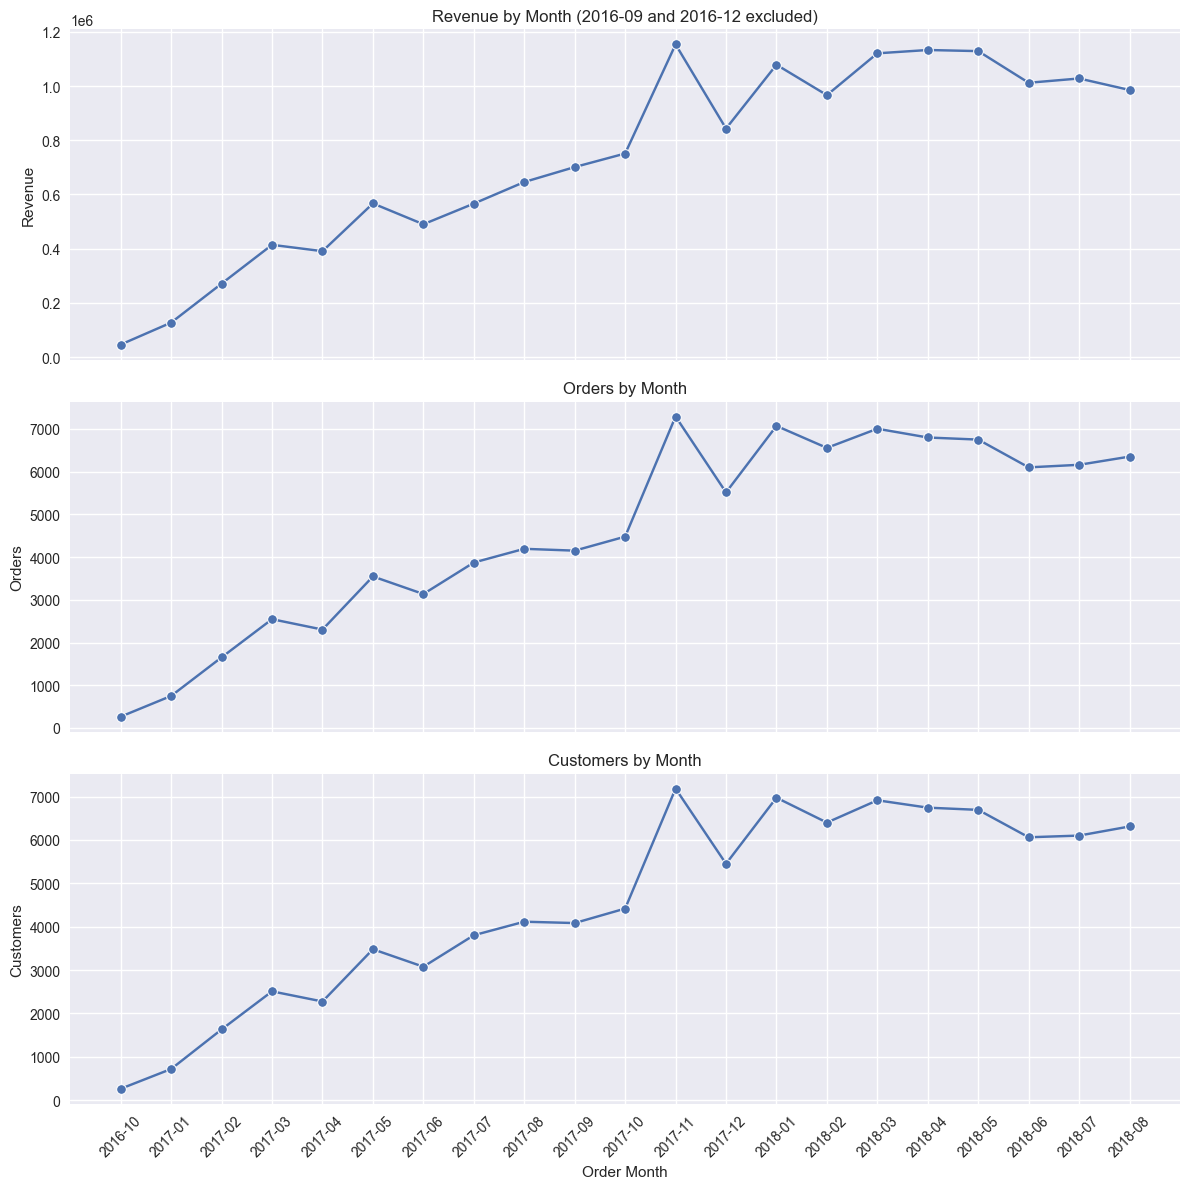

In [15]:
# monthly metrics được tính ở cấp độ đơn hàng sử dụng payment_value để phản ánh doanh thu thực tế của mỗi đơn hàng, tránh việc tính trùng lặp nếu một đơn hàng có nhiều mục sản phẩm.
monthly_metrics_raw = (
    df_orders.groupby("order_month", as_index=False)
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
    )
    .sort_values("order_month")
)

# loại bỏ 2 tháng đầu tiên có doanh thu thấp để tránh việc hiểu sai về xu hướng tăng trưởng do giai đoạn đầu có thể chưa ổn định hoặc có dữ liệu thiếu.
monthly_metrics = monthly_metrics_raw[
    ~monthly_metrics_raw["order_month"].isin(["2016-09", "2016-12"])
].copy()

display(monthly_metrics.head(10))

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(data=monthly_metrics, x="order_month", y="revenue", marker="o", ax=axes[0])
axes[0].set_title("Revenue by Month (2016-09 and 2016-12 excluded)")
axes[0].set_ylabel("Revenue")

sns.lineplot(data=monthly_metrics, x="order_month", y="orders", marker="o", ax=axes[1])
axes[1].set_title("Orders by Month")
axes[1].set_ylabel("Orders")

sns.lineplot(data=monthly_metrics, x="order_month", y="customers", marker="o", ax=axes[2])
axes[2].set_title("Customers by Month")
axes[2].set_ylabel("Customers")
axes[2].set_xlabel("Order Month")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

,customer_state,revenue,orders,customers,revenue_per_customer
25,SP,"5,770,266.19",40501,39156,147.37
18,RJ,"2,055,690.45",12350,11917,172.50
10,MG,"1,819,277.61",11354,11001,165.37
22,RS,"861,802.40",5345,5168,166.76
17,PR,"781,919.55",4923,4769,163.96
23,SC,"595,208.40",3546,3449,172.57
4,BA,"591,270.60",3256,3158,187.23
6,DF,"346,146.17",2080,2019,171.44
8,GO,"334,294.22",1957,1895,176.41
7,ES,"317,682.65",1995,1928,164.77


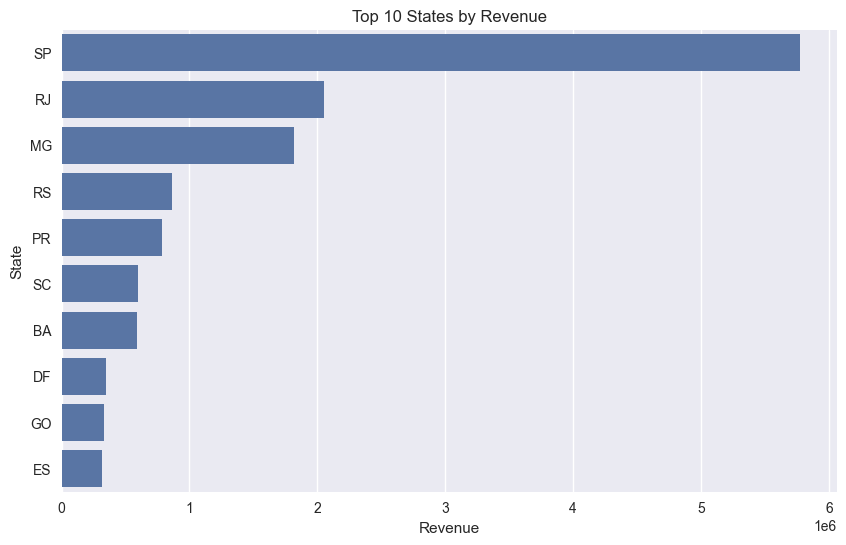

,customer_state,revenue,orders,customers,revenue_per_customer
14,PB,"137,834.65",517,504,273.48
0,AC,"19,586.25",80,76,257.71
20,RO,"56,975.70",243,231,246.65
3,AP,"16,141.81",67,66,244.57
1,AL,"94,195.79",397,387,243.40
13,PA,"212,027.55",946,922,229.96
16,PI,"105,272.17",476,464,226.88
21,RR,"9,039.52",41,40,225.99
26,TO,"60,007.37",274,267,224.75
19,RN,"100,728.30",474,464,217.09


In [16]:
# phân tích theo state được thực hiện theo bảng df_orders, sử dụng payment_value để đảm bảo tính nhất quán với phân tích theo tháng và phản ánh doanh thu thực tế từ mỗi đơn hàng.
state_summary = (
    df_orders.groupby("customer_state", as_index=False)
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
    )
)
state_summary["revenue_per_customer"] = state_summary["revenue"] / state_summary["customers"]
state_summary = state_summary.sort_values("revenue", ascending=False)

display(state_summary.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=state_summary.head(10), x="revenue", y="customer_state")
plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")
plt.show()

display(state_summary.sort_values("revenue_per_customer", ascending=False).head(10))

In [17]:
df_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,customer_unique_id,customer_city,customer_state,product_category_name,product_category_name_english,item_revenue,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,cool_stuff,cool_stuff,72.19,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,pet_shop,pet_shop,259.83,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,moveis_decoracao,furniture_decor,216.87,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,perfumaria,perfumery,25.78,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,ferramentas_jardim,garden_tools,218.04,2017-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,2018-04-23 13:57:06,0c9aeda10a71f369396d0c04dce13a64,sao luis,MA,utilidades_domesticas,housewares,343.40,2018-04
110193,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,2018-07-14 10:26:46,0da9fe112eae0c74d3ba1fe16de0988b,curitiba,PR,informatica_acessorios,computers_accessories,386.53,2018-07
110194,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,2017-10-23 17:07:56,cd79b407828f02fdbba457111c38e4c4,sao paulo,SP,esporte_lazer,sports_leisure,116.85,2017-10
110195,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,2017-08-14 23:02:59,eb803377c9315b564bdedad672039306,vinhedo,SP,informatica_acessorios,computers_accessories,64.71,2017-08


,product_category_name_english,item_revenue,orders,quantity
43,health_beauty,"1,412,089.53",8647,9465
71,watches_gifts,"1,264,333.12",5495,5859
7,bed_bath_table,"1,225,209.26",9272,10953
65,sports_leisure,"1,118,256.91",7530,8431
15,computers_accessories,"1,032,723.77",6530,7644
39,furniture_decor,"880,329.92",6307,8160
49,housewares,"758,392.25",5743,6795
20,cool_stuff,"691,680.89",3559,3718
5,auto,"669,454.75",3810,4140
42,garden_tools,"567,145.68",3448,4268


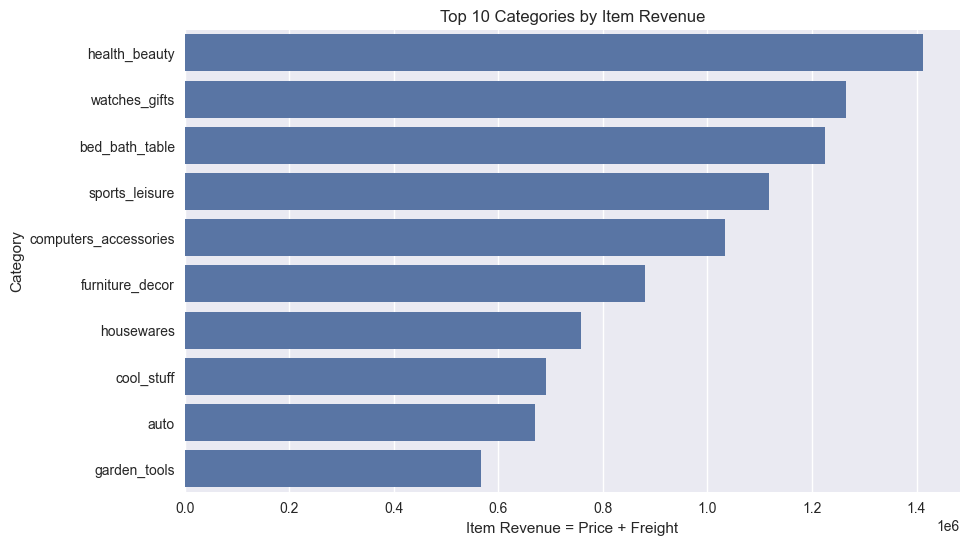

In [18]:
#tạo bảng category_summary từ df_items để phân tích doanh thu, số đơn hàng và số lượng sản phẩm theo category
category_summary = (
    df_items.groupby("product_category_name_english", as_index=False)
    .agg(
        item_revenue=("item_revenue", "sum"),
        orders=("order_id", "nunique"),
        quantity=("order_item_id", "count"),
    )
    .sort_values("item_revenue", ascending=False)
)

display(category_summary.head(10))

#vẽ bar chart để phân tích doanh thu theo category, chỉ lấy top 10 category có doanh thu cao nhất
plt.figure(figsize=(10, 6))
sns.barplot(data=category_summary.head(10), x="item_revenue", y="product_category_name_english")
plt.title("Top 10 Categories by Item Revenue")
plt.xlabel("Item Revenue = Price + Freight")
plt.ylabel("Category")
plt.show()


,payment_type,payment_value,orders
1,credit_card,"12,101,094.88",74304
0,boleto,"2,769,932.58",19191
3,voucher,"343,013.19",3679
2,debit_card,"208,421.12",1485


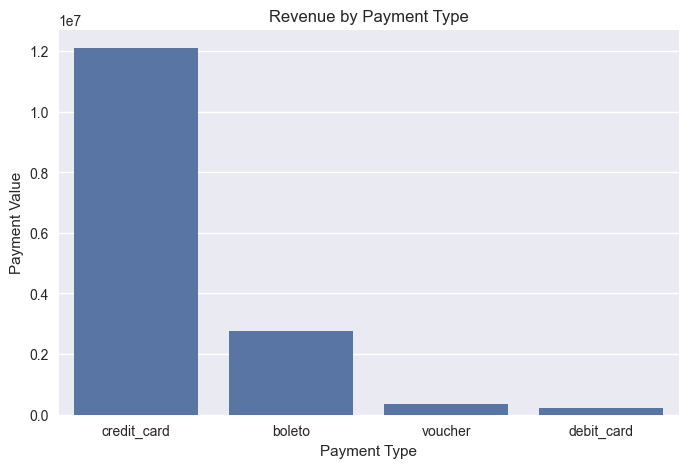

In [19]:
#Lọc payments chỉ còn các đơn có trong df_orders (các đơn đã giao thành công)
delivered_payments = payments[payments["order_id"].isin(df_orders["order_id"])]

#nhóm theo payment_type để phân tích doanh thu theo phương thức thanh toán
payment_summary = (
    delivered_payments.groupby("payment_type", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values("payment_value", ascending=False)
)

display(payment_summary)

#vẽ bar chart để phân tích doanh thu theo phương thức thanh toán
plt.figure(figsize=(8, 5))
sns.barplot(data=payment_summary, x="payment_type", y="payment_value")
plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")
plt.show()


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

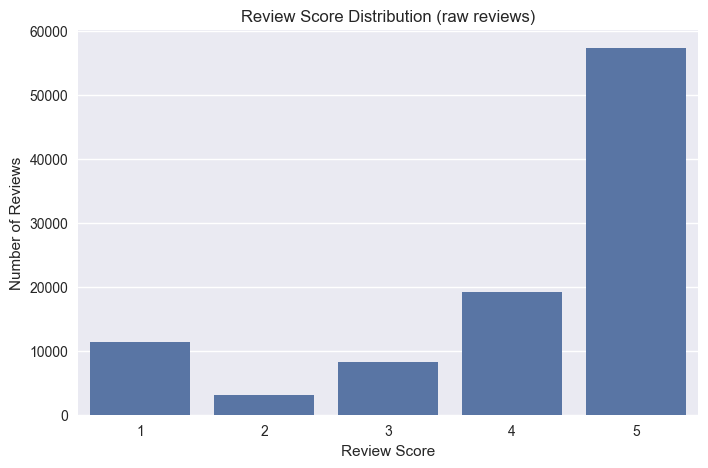

In [20]:
# Review distribution for dashboard is based on raw reviews (1-5 stars).
# phân bố điểm đánh giá được tính dựa trên các đánh giá thô (1-5 sao) trong bảng reviews
review_counts = reviews["review_score"].value_counts().sort_index()
display(review_counts)


plt.figure(figsize=(8, 5))
sns.countplot(data=reviews, x="review_score", order=[1, 2, 3, 4, 5])
plt.title("Review Score Distribution (raw reviews)")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.show()

## 5. Customer Insights


,Metric,Value
0,One-time Customers,"90,557.00"
1,Repeat Customers,"2,801.00"
2,Repeat Rate (%),3.00


,buyer_type,customers,total_revenue,avg_customer_value,customer_pct,revenue_pct
0,One-time Buyer,90557,"14,558,104.56",160.76,97.00,94.40
1,Repeat Buyer,2801,"864,357.21",308.59,3.00,5.60


num_orders
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

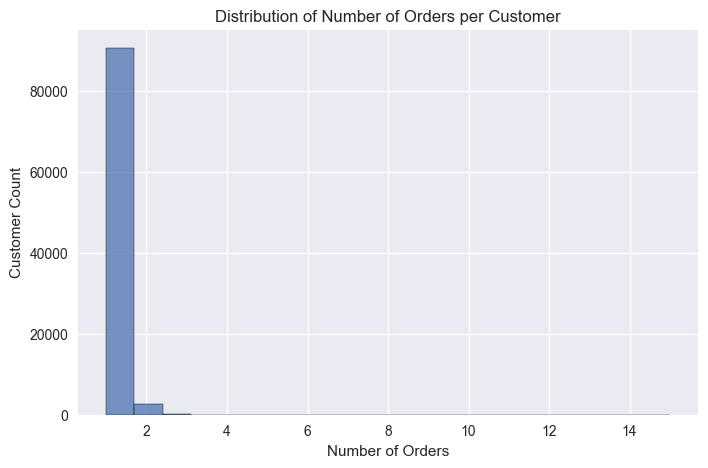

,customer_unique_id,total_spent,total_orders,aov
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89


,customer_unique_id,total_spent,total_orders,aov
3724,0a0a92112bd4c708ca5fde585afaa872,"13,664.08",1,"13,664.08"
79636,da122df9eeddfedc1dc1f5349a1a690c,"7,571.63",2,"3,785.82"
43168,763c8b1c9c68a0229c42c9fc6f662b93,"7,274.88",1,"7,274.88"
80463,dc4802a71eae9be1dd28f5d788ceb526,"6,929.31",1,"6,929.31"
25436,459bef486812aa25204be022145caa62,"6,922.21",1,"6,922.21"
93081,ff4159b92c40ebe40454e3e6a7c35ed6,"6,726.66",1,"6,726.66"
23411,4007669dec559734d6f53e029e360987,"6,081.54",1,"6,081.54"
87148,eebb5dda148d3893cdaf5b5ca3040ccb,"4,764.34",1,"4,764.34"
26640,48e1ac109decbb87765a3eade6854098,"4,681.78",1,"4,681.78"
73127,c8460e4251689ba205045f3ea17884a1,"4,655.91",4,"1,163.98"


In [21]:
# Phân tích repeat-rate là phát hiện kinh doanh cốt lõi của notebook này
# customer_order_counts tính bằng cách nhóm theo customer_unique_id để đảm bảo tính chính xác về số lượng khách hàng thực sự, tránh việc đếm trùng nếu một khách hàng có nhiều customer_id khác nhau.
customer_order_counts = (
    df_orders.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

one_time_customers = (customer_order_counts["num_orders"] == 1).sum() #số khách hàng chỉ mua 1 lần
repeat_customers = (customer_order_counts["num_orders"] > 1).sum() #số khách hàng mua nhiều lần
repeat_rate = repeat_customers / len(customer_order_counts) * 100 #tỷ lệ khách hàng mua lại

repeat_kpi = pd.DataFrame(
    {
        "Metric": ["One-time Customers", "Repeat Customers", "Repeat Rate (%)"],
        "Value": [one_time_customers, repeat_customers, repeat_rate],
    }
)
display(repeat_kpi)

# customer_value tính bằng cách nhóm theo customer_unique_id, sử dụng payment_value để phản ánh tổng doanh thu thực tế từ mỗi khách hàng, tránh việc tính trùng nếu một khách hàng có nhiều đơn hàng.
customer_value = (
    df_orders.groupby("customer_unique_id", as_index=False)
    .agg(
        total_spent=("payment_value", "sum"),
        total_orders=("order_id", "nunique"),
    )
)
customer_value["aov"] = customer_value["total_spent"] / customer_value["total_orders"] 

repeat_summary = customer_order_counts.merge(customer_value, on="customer_unique_id", how="left") 
repeat_summary["buyer_type"] = np.where(repeat_summary["num_orders"] > 1, "Repeat Buyer", "One-time Buyer")

# repeat_revenue được tính bằng cách nhóm theo buyer_type để phân tích doanh thu, số lượng khách hàng và giá trị trung bình của khách hàng giữa nhóm mua một lần và nhóm mua lại.
repeat_revenue = (
    repeat_summary.groupby("buyer_type", as_index=False)
    .agg(
        customers=("customer_unique_id", "count"),
        total_revenue=("total_spent", "sum"),
        avg_customer_value=("total_spent", "mean"),
    )
)
repeat_revenue["customer_pct"] = repeat_revenue["customers"] / repeat_revenue["customers"].sum() * 100 #tỷ lệ khách hàng trong mỗi nhóm so với tổng số khách hàng
repeat_revenue["revenue_pct"] = repeat_revenue["total_revenue"] / repeat_revenue["total_revenue"].sum() * 100 #tỷ lệ doanh thu trong mỗi nhóm so với tổng doanh thu
 
display(repeat_revenue.round(2))
display(customer_order_counts["num_orders"].value_counts().sort_index().head(10))

plt.figure(figsize=(8, 5))
sns.histplot(customer_order_counts["num_orders"], bins=20)
plt.title("Distribution of Number of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Customer Count")
plt.show()

display(customer_value.head())
display(customer_value.sort_values("total_spent", ascending=False).head(10))

**Key insight**

- Tỉ lệ mua lại khoảng 3%, nên vấn đề kinh doanh chính cần xử lý là thu hút khách hàng quay lại
- Frequency tập trung rất mạnh ở mức 1 đơn hàng, vì vậy việc phân cụm khách hàng chủ yếu bị chi phối bởi Recency và Monetary.
- Lưu ý về doanh thu: Các chỉ số KPI, phân tích theo bang (state), theo cụm khách hàng (cluster) và xu hướng theo thời gian (monthly trend) sử dụng payment_value ở cấp độ đơn hàng (order-level); trong khi đó, phân tích theo danh mục sản phẩm (category) sử dụng item_revenue = price + freight_value ở cấp độ từng sản phẩm (item-level).

## 6. Customer Segmentation: 12-Month RFM + KMeans

In [22]:
# Xây dựng RFM theo 12 tháng gần nhất để Rencency có thể so sánh được giữa các khách hàng.
analysis_end = df_orders["order_purchase_timestamp"].max()
analysis_start = analysis_end - pd.DateOffset(months=12)

df_orders_rfm = df_orders[
    (df_orders["order_purchase_timestamp"] >= analysis_start)
    & (df_orders["order_purchase_timestamp"] <= analysis_end)
].copy()

# Snapshot date được đặt vào ngày sau ngày đặt hàng mới nhất để đảm bảo rằng recency được tính chính xác cho tất cả khách hàng, kể cả những khách hàng có đơn hàng gần nhất vào ngày phân tích.
snapshot_date = analysis_end + pd.Timedelta(days=1)

# rfm được tính bằng cách nhóm theo customer_unique_id để đảm bảo rằng mỗi khách hàng được tính một lần duy nhất, tránh việc tính trùng nếu một khách hàng có nhiều đơn hàng. 
# Recency được tính dựa trên ngày mua hàng gần nhất của mỗi khách hàng so với snapshot_date
# Frequency được tính bằng số lượng đơn hàng duy nhất của mỗi khách hàng vì một khách hàng có thể có nhiều đơn hàng nhưng chỉ được tính là 1 lần mua nếu chúng thuộc cùng một đơn hàng (order_id), điều này giúp tránh việc đếm trùng nếu một khách hàng có nhiều đơn hàng trong cùng một khoảng thời gian.
# Monetary được tính bằng tổng giá trị thanh toán của mỗi khách hàng trong khoảng thời gian phân tích

rfm = df_orders_rfm.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("payment_value", "sum"),
)

# Cap extreme spenders trước khi phân cụm vì KMeans nhạy cảm với các giá trị ngoại lai. Việc này giúp cải thiện chất lượng phân cụm bằng cách giảm ảnh hưởng của những khách hàng có giá trị mua hàng cực kỳ cao.
monetary_cap = rfm["Monetary"].quantile(0.99)
rfm["Monetary_capped"] = rfm["Monetary"].clip(upper=monetary_cap)

rfm_scope_note = pd.DataFrame(
    {
        "metric": [
            "analysis_start",
            "analysis_end",
            "customers_in_rfm",
            "pct_frequency_eq_1",
            "monetary_cap_p99",
        ],
        "value": [
            str(analysis_start.date()),
            str(analysis_end.date()),
            int(len(rfm)),
            round((rfm["Frequency"].eq(1).mean() * 100), 2),
            round(monetary_cap, 2),
        ],
    }
)
display(rfm_scope_note)
display(rfm.head())

,metric,value
0,analysis_start,2017-08-29
1,analysis_end,2018-08-29
2,customers_in_rfm,72620
3,pct_frequency_eq_1,97.51
4,monetary_cap_p99,"1,104.30"


,Recency,Frequency,Monetary,Monetary_capped
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,27.19
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,196.89
0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,166.98


**rfm_scope_note**
- Phân tích RFM trong 12 tháng (từ 29/08/2017 - 29/08/2018)
- Số khách hàng phát sinh đơn trong 12 tháng là 72.620 -> một số khách hàng đã "inactive"
- pct_frequency_eq_1 = 97.51% -> 97.51% khách chỉ mua 1 lần -> hầu như KHÔNG CÓ repeat customer -> Frequency gần như vô nghĩa trong phân cụm
- monetary_cap_p99 = 1,104.30 -> 99% khách chi dưới 1104 -> top 1% khách chi tiêu rất cao (outlier)

**Pattern**
- Frequency = 1 -> dataset khong có repeat behavior
- Recency dao động lớn (112 - 321) -> có khách mới, có khách đã rời bỏ
- Monetary chênh lệch lớn -> có khách giá trị cao và thấp

**INSIGHT**
- Hành vi mua sắm của khách hàng có sự chênh lệch lớn, với 97.5% khách hàng chỉ mua 1 lần. Điều này cho thấy việc thu hút khách hàng quay trở lại là vấn đề quan trọng, và phân cụm chỉ dựa vào Rencency và Monetary hơn là Frequency

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Log-transform trước khi scaling để model được huấn luyện trên cùng một không gian biến đổi được sử dụng cho các biểu đồ, giúp cải thiện hiệu suất của KMeans và đảm bảo rằng các phân cụm phản ánh đúng sự khác biệt giữa khách hàng về tần suất mua hàng và giá trị mua hàng.
rfm["log_Frequency"] = np.log1p(rfm["Frequency"])
rfm["log_Monetary"] = np.log1p(rfm["Monetary_capped"])

# Chỉ sử dụng các cột Recency, log_Frequency và log_Monetary đã được xử lý để phân cụm vì chúng đã được chuẩn hóa và biến đổi phù hợp cho KMeans, giúp cải thiện chất lượng phân cụm và đảm bảo rằng các phân cụm phản ánh đúng sự khác biệt giữa khách hàng về thời gian mua hàng gần nhất, tần suất mua hàng và giá trị mua hàng.
model_features = rfm[["Recency", "log_Frequency", "log_Monetary"]]
# Scaling dữ liệu trước khi phân cụm để đảm bảo rằng tất cả các biến đều có cùng một thang đo, giúp KMeans hoạt động hiệu quả hơn và tạo ra các phân cụm có ý nghĩa hơn.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(model_features)

# Chạy KMeans với k từ 3 đến 5 để tìm số lượng phân cụm tối ưu dựa trên điểm inertia và silhouette score, giúp xác định số lượng phân cụm phù hợp nhất để phân đoạn khách hàng.
score_rows = []
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20) 
    labels = km.fit_predict(rfm_scaled) #fit_predict vừa huấn luyện mô hình KMeans trên dữ liệu đã được chuẩn hóa, vừa gán nhãn phân cụm cho từng khách hàng trong cùng một bước, giúp tiết kiệm thời gian và đảm bảo rằng các nhãn phân cụm phản ánh chính xác kết quả của mô hình.
    score_rows.append({ 
        "k": k,
        "inertia": km.inertia_, #tổng khoảng cách từ điểm đến centroid, giá trị càng nhỏ thì cụm càng chặt
        "silhouette": silhouette_score(rfm_scaled, labels), #độ tách biệt giữa các cụm, giá trị từ -1 đến 1, giá trị càng cao thì phân cụm càng tốt
    })

score_df = pd.DataFrame(score_rows)
display(score_df)

,k,inertia,silhouette
0,3,"95,768.42",0.36
1,4,"66,094.10",0.37
2,5,"51,644.79",0.35


In [24]:
# Ưu tiên k=4 khi điểm silhouette của nó gần với điểm tốt nhất vì 4 phân đoạn dễ sử dụng trong marketing.
best_silhouette = score_df["silhouette"].max() # lấy điểm silhouette tốt nhất trong các giá trị k đã thử
silhouette_k4 = score_df.loc[score_df["k"] == 4, "silhouette"].iloc[0]
if abs(best_silhouette - silhouette_k4) <= 0.02:
    best_k = 4
    print("Using k=4 because its silhouette is close to the best score and it is more interpretable for marketing.")
else:
    best_k = int(score_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
    print(f"Using k={best_k} because it has the strongest silhouette score.")

Using k=4 because its silhouette is close to the best score and it is more interpretable for marketing.


In [25]:
# Chạy KMeans và gán Cluster Labels cho mỗi khách hàng dựa trên số lượng phân cụm tối ưu đã chọn, giúp phân đoạn khách hàng thành các nhóm có đặc điểm tương đồng về recency, frequency và monetary value.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

# Tạo profile cho mỗi cluster bằng cách tính trung bình của Recency, Frequency và Monetary trong mỗi cluster, giúp hiểu rõ hơn về đặc điểm của từng phân đoạn khách hàng.
cluster_profile = (
    rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

# Name clusters based on actual cluster profile instead of hard-coded row rules.
# Gắn tên cho các cluster dựa theo profile thực tế, giúp đảm bảo rằng tên phân đoạn phản ánh đúng đặc điểm của khách hàng trong mỗi cluster và dễ hiểu hơn cho mục đích marketing.
segment_map = {}
repeat_cluster = cluster_profile["Frequency"].idxmax() #tìm cluster có Frequency cao nhất
segment_map[repeat_cluster] = "Repeat Buyers"

remaining_clusters = [c for c in cluster_profile.index if c not in segment_map] #tạo danh sách các cluster còn lại sau khi đã gán cho cluster Frequency cao nhất
high_value_cluster = cluster_profile.loc[remaining_clusters, "Monetary"].idxmax() #tìm cluster có Monetary cao nhất trong số các cluster còn lại
segment_map[high_value_cluster] = "High-Value One-timers"

remaining_clusters = [c for c in cluster_profile.index if c not in segment_map] #tạo danh sách các cluster còn lại sau khi đã gán cho cluster Monetary cao nhất
churn_cluster = cluster_profile.loc[remaining_clusters, "Recency"].idxmax() #tìm cluster có Recency cao nhất trong số các cluster còn lại
segment_map[churn_cluster] = "Churned"

remaining_clusters = [c for c in cluster_profile.index if c not in segment_map] #tạo danh sách các cluster còn lại sau khi đã gán cho cluster Recency cao nhất
for c in remaining_clusters:
    segment_map[c] = "Recent Low-Value"

rfm["segment"] = rfm["cluster"].map(segment_map) #gán tên phân đoạn cho từng khách hàng dựa trên cluster mà họ thuộc về, giúp dễ dàng phân tích và áp dụng các chiến lược marketing phù hợp với từng phân đoạn khách hàng.
cluster_profile["segment"] = cluster_profile.index.map(segment_map) #gán nhãncho profile của từng cluster để dễ dàng hiểu và trình bày đặc điểm của mỗi phân đoạn khách hàng.
display(cluster_profile.sort_index())

,Recency,Frequency,Monetary,segment
cluster,,,,
0,81.49,1.00,92.63,Recent Low-Value
1,158.49,2.10,310.21,Repeat Buyers
2,265.33,1.00,86.36,Churned
3,179.53,1.00,367.39,High-Value One-timers


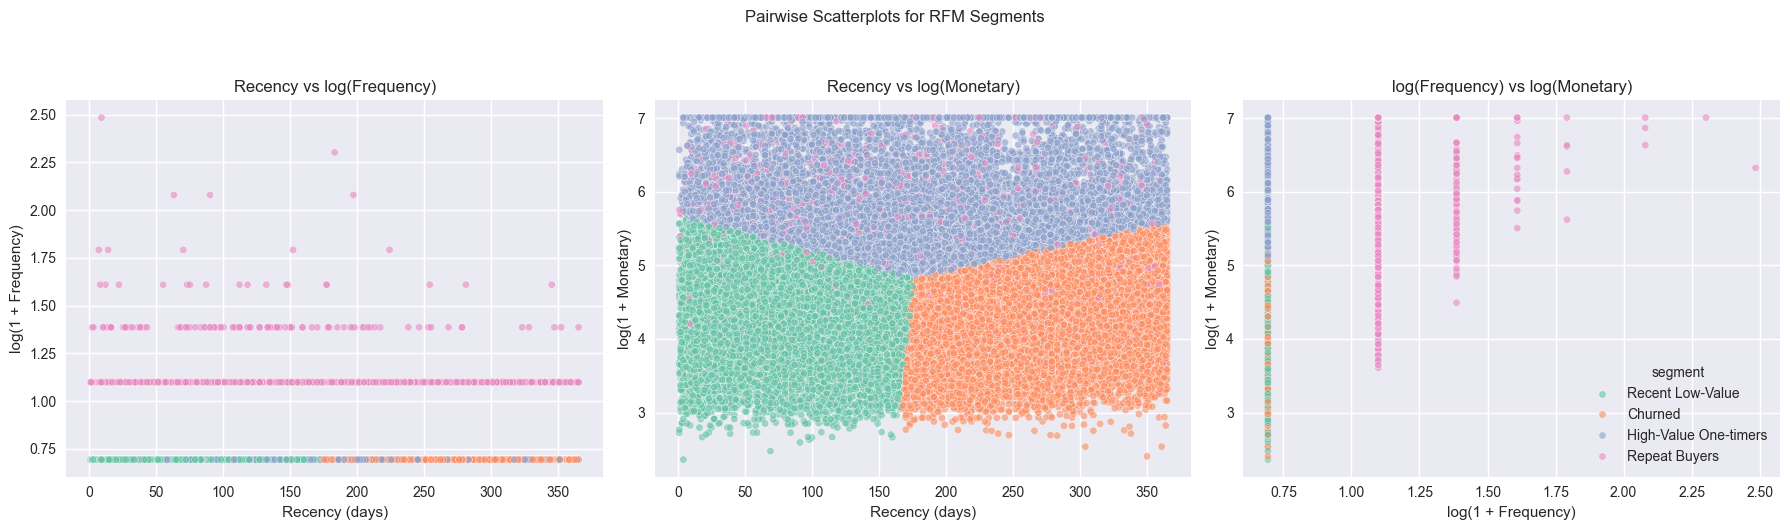

In [26]:
plot_rfm = rfm.reset_index().copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=plot_rfm,
    x="Recency",
    y="log_Frequency",
    hue="segment",
    palette="Set2",
    s=28,
    alpha=0.6,
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Recency vs log(Frequency)")
axes[0].set_xlabel("Recency (days)")
axes[0].set_ylabel("log(1 + Frequency)")

sns.scatterplot(
    data=plot_rfm,
    x="Recency",
    y="log_Monetary",
    hue="segment",
    palette="Set2",
    s=28,
    alpha=0.6,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Recency vs log(Monetary)")
axes[1].set_xlabel("Recency (days)")
axes[1].set_ylabel("log(1 + Monetary)")

sns.scatterplot(
    data=plot_rfm,
    x="log_Frequency",
    y="log_Monetary",
    hue="segment",
    palette="Set2",
    s=28,
    alpha=0.6,
    ax=axes[2],
)
axes[2].set_title("log(Frequency) vs log(Monetary)")
axes[2].set_xlabel("log(1 + Frequency)")
axes[2].set_ylabel("log(1 + Monetary)")

plt.suptitle("Pairwise Scatterplots for RFM Segments", y=1.05)
plt.tight_layout()
plt.show()

**CHART 1. Recency vs log(Frequency)**
- Ý nghĩa: khách mua gần đây và số lần mua
- log(F) tập trung ở 0.7 và 1.1 tức Frequency = 1 hoặc 2
=> Frequency không biệt được khách hàng

**CHART 2. Recency vs log(Monetary)**
- Ý nghĩa: khách mua gần đây và chi tiêu
- Biểu đồ chia rõ thành 3 vùng
+ Recent Low-Value: recency thấp và monetary thấp => Khách mới, chi ít
+ High-value One-timers: monetary cao và rencency trải rộng => Khách chi nhiều nhưng không quay lại
+ Churned: Rencency cao (lâu không mua) và Monetary thấp, trung bình => Khách đã rời bỏ
=> Insight chính
+ Cluster đang tách chủ yếu theo Chi tiêu (Monetary) và Độ mới (Rencency)

**CHART 3. log(Frequency) và log(Monetary)**
- Ý nghĩa: tần suất và giá trị
- Frequency gần như riêng rẽ và không đa dạng 
- Chỉ có Monetary tạo ra sư khác biệt 

**KẾT LUẬN** 
- Phân khúc khách hàng chủ yếu bị chi phối bởi Recency và Monetary vì Frequency gần như bằng 1 với hầu hết khách hàng. Điều này cho thấy doanh nghiệp đang gặp vấn đề nghiêm trọng về giữ chân khách hàng, khi phần lớn khách chỉ mua một lần. Do đó, trọng tâm không nên chỉ là phân nhóm mà cần chuyển sang cải thiện hành vi mua lại.

In [27]:
# Đo giá trị kinh doanh của từng cluster
cluster_value = (
    plot_rfm.groupby(["cluster", "segment"], as_index=False)
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
        total_revenue=("Monetary", "sum"),
    )
)
cluster_value["customer_pct"] = cluster_value["customers"] / cluster_value["customers"].sum() * 100
cluster_value["revenue_pct"] = cluster_value["total_revenue"] / cluster_value["total_revenue"].sum() * 100
cluster_value["aov_proxy"] = cluster_value["total_revenue"] / cluster_value["customers"]
display(cluster_value.round(2))

,cluster,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customer_pct,revenue_pct,aov_proxy
0,0,Recent Low-Value,26667,81.49,1.00,92.63,"2,470,206.54",36.72,20.62,92.63
1,1,Repeat Buyers,1810,158.49,2.10,310.21,"561,475.53",2.49,4.69,310.21
2,2,Churned,25870,265.33,1.00,86.36,"2,234,024.41",35.62,18.65,86.36
3,3,High-Value One-timers,18273,179.53,1.00,367.39,"6,713,379.29",25.16,56.04,367.39


**INSIGHT**
- Doanh thu tập trung chủ yếu ở nhóm High-Value One-timers, chiếm 25% khách nhưng tạo ra hơn 56% doanh thu. Tuy nhiên nhóm này không quay lại, cho thấy doanh nghiệp đang thất thoát khách hàng giá trị cao.

- Ngoài ra, nhóm Repeat Buyers chỉ chiếm 2.5% tổng số khách, cho thấy mức độ trung thành rất thấp. Điều này chứng minh vấn đề cốt lõi không phải là thu hút khách hàng mới mà là giữ chân khách hàng và chuyển đổi khách mua một lần thành khách mua lại.

In [28]:
# Gắn nhãn cluster vào df_orders và df_items để phân tích đặc điểm của khách hàng trong từng cluster dựa trên các thuộc tính khác như địa lý, danh mục sản phẩm và phương thức thanh toán.
rfm_reset = plot_rfm[["customer_unique_id", "cluster", "segment"]]
df_orders_cluster = df_orders.merge(rfm_reset, on="customer_unique_id", how="left")
df_items_cluster = df_items.merge(rfm_reset, on="customer_unique_id", how="left")
delivered_payments_cluster = delivered_payments.merge(
    df_orders_cluster[["order_id", "cluster", "segment"]],
    on="order_id",
    how="left",
)


In [29]:
# Đo lường theo review_score
cluster_review = (
    df_orders_cluster.groupby(["cluster", "segment"], as_index=False)
    .agg(avg_review_score=("review_score", "mean"))
)
display(cluster_review.round(2))

,cluster,segment,avg_review_score
0,0.00,Recent Low-Value,4.27
1,1.00,Repeat Buyers,4.20
2,2.00,Churned,4.11
3,3.00,High-Value One-timers,3.96


- Avg review score ở mức 4.0 cho thấy khách hàng trong tất cả các phân đoạn đều có xu hướng hài lòng với sản phẩm và dịch vụ
- Điều này có thể là một điểm mạnh cho Olist khi xây dựng chiến lược giữ chân khách hàng và khuyến khích mua lại. 

In [30]:
# Đo lường theo state
cluster_state = (
    df_orders_cluster.groupby(["cluster", "segment", "customer_state"], as_index=False)
    .agg(revenue=("payment_value", "sum"), customers=("customer_unique_id", "nunique"))
    .sort_values(["cluster", "revenue"], ascending=[True, False])
)
display(cluster_state.groupby(["cluster", "segment"]).head(3))

,cluster,segment,customer_state,revenue,customers
25,0.00,Recent Low-Value,SP,"1,104,274.12",12780
18,0.00,Recent Low-Value,RJ,"305,504.97",3072
10,0.00,Recent Low-Value,MG,"288,993.28",2965
51,1.00,Repeat Buyers,SP,"238,452.78",824
44,1.00,Repeat Buyers,RJ,"75,414.51",246
36,1.00,Repeat Buyers,MG,"66,712.56",214
78,2.00,Churned,SP,"901,525.94",10897
71,2.00,Churned,RJ,"306,830.70",3357
63,2.00,Churned,MG,"282,571.40",3123
105,3.00,High-Value One-timers,SP,"2,335,656.28",6570


- Hành vi mua sắm giữa các cluster không có sự khác biệt theo địa lý

In [31]:
# Đo lường theo category
cluster_category = (
    df_items_cluster.groupby(["cluster", "segment", "product_category_name_english"], as_index=False)
    .agg(item_revenue=("item_revenue", "sum"))
    .sort_values(["cluster", "item_revenue"], ascending=[True, False])
)
display(cluster_category.groupby(["cluster", "segment"]).head(3))

,cluster,segment,product_category_name_english,item_revenue
43,0.00,Recent Low-Value,health_beauty,"271,222.13"
7,0.00,Recent Low-Value,bed_bath_table,"252,087.38"
69,0.00,Recent Low-Value,watches_gifts,"196,278.41"
77,1.00,Repeat Buyers,bed_bath_table,"70,519.21"
132,1.00,Repeat Buyers,sports_leisure,"50,580.48"
107,1.00,Repeat Buyers,furniture_decor,"49,795.65"
145,2.00,Churned,bed_bath_table,"259,105.04"
202,2.00,Churned,sports_leisure,"204,124.07"
180,2.00,Churned,health_beauty,"181,243.76"
275,3.00,High-Value One-timers,watches_gifts,"707,404.21"


- Không có sự khác biệt giữa các nhóm Recent Low-Value/ Repeat Buyers/ Churned => Category không phải yếu tố quyết định churn
- Nhóm High-Value One-timers mua sản phẩm có giá trị cao (watches_gifts và computer_accessories) nên ít mua lặp lại
- Phân tích danh mục sản phẩm cho thấy nhóm khách hàng giá trị cao thường mua các sản phẩm như đồng hồ, quà tặng và thiết bị điện tử – đây là các sản phẩm có tần suất mua lặp lại thấp. Điều này giải thích vì sao tỷ lệ khách hàng quay lại thấp, do khách hàng không có nhu cầu mua lại các sản phẩm này trong ngắn hạn.

In [32]:
# Đo lường theo payment_type
cluster_payment = (
    delivered_payments_cluster.groupby(["cluster", "segment", "payment_type"], as_index=False)
    .agg(payment_value=("payment_value", "sum"))
    .sort_values(["cluster", "payment_value"], ascending=[True, False])
)
display(cluster_payment.groupby(["cluster", "segment"]).head(3))

,cluster,segment,payment_type,payment_value
1,0.00,Recent Low-Value,credit_card,"1,904,839.59"
0,0.00,Recent Low-Value,boleto,"454,353.71"
3,0.00,Recent Low-Value,voucher,"64,315.65"
5,1.00,Repeat Buyers,credit_card,"426,190.97"
4,1.00,Repeat Buyers,boleto,"119,870.19"
7,1.00,Repeat Buyers,voucher,"17,458.10"
9,2.00,Churned,credit_card,"1,708,143.74"
8,2.00,Churned,boleto,"470,623.68"
11,2.00,Churned,voucher,"68,077.51"
13,3.00,High-Value One-timers,credit_card,"5,478,677.93"


- Khách hàng có khả năng chi trả tốt
- Không phải vấn đề tài chính mà là hành vi mua
- Việc khách hàng không quay lại không xuất phát từ trải nghiệm kém hay hạn chế thanh toán, mà do đặc thù sản phẩm và hành vi mua hàng. Nhóm khách hàng giá trị cao thường mua các sản phẩm không có tính lặp lại, dẫn đến tỷ lệ quay lại thấp dù tạo ra doanh thu lớn ban đầu.

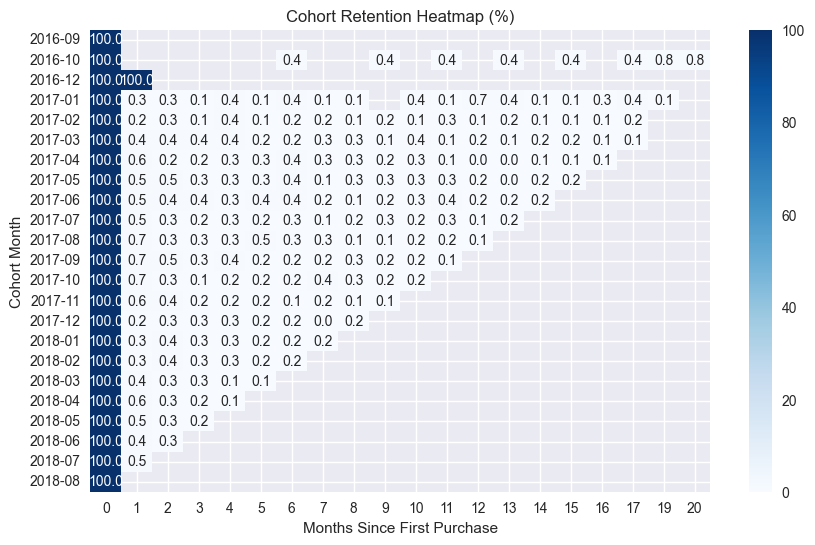

In [33]:
# Phân tích nhóm khách hàng để thể hiện tỷ lệ giữ chân khách hàng theo tháng mua hàng đầu tiên 
cohort = df_orders.copy()
cohort["order_month_period"] = cohort["order_purchase_timestamp"].dt.to_period("M") #biến đổi ngày sang định dạng tháng để phân tích theo tháng mua hàng đầu tiên, giúp dễ dàng tính toán khoảng thời gian giữa các đơn hàng và tháng mua hàng đầu tiên của khách hàng.
first_purchase = cohort.groupby("customer_unique_id")["order_month_period"].min().reset_index() #tính tháng mua hàng đầu tiên của mỗi khách hàng bằng cách nhóm theo customer_unique_id và lấy giá trị nhỏ nhất của order_month_period, giúp xác định cohort của mỗi khách hàng dựa trên tháng mua hàng đầu tiên của họ.
first_purchase.columns = ["customer_unique_id", "cohort_month"] 

cohort = cohort.merge(first_purchase, on="customer_unique_id", how="left") #merge để gán cohort_month cho mỗi đơn hàng dựa trên customer_unique_id, giúp xác định tháng mua hàng đầu tiên của khách hàng cho mỗi đơn hàng và từ đó tính toán khoảng thời gian giữa tháng mua hàng đầu tiên và tháng của đơn hàng.
cohort["period_number"] = (cohort["order_month_period"] - cohort["cohort_month"]).apply(lambda x: x.n) #tính số tháng từ lần mua đầu

cohort_data = (
    cohort.groupby(["cohort_month", "period_number"])["customer_unique_id"]
    .nunique()
    .reset_index()
) #đếm số khách hàng duy nhất trong mỗi cohort_month và period_number => mỗi cohort, mỗi tháng có bao nhiêu khách quay lại

cohort_pivot = cohort_data.pivot(index="cohort_month", columns="period_number", values="customer_unique_id")
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100 #tính retention => % khách hàng còn quay lại so với ban đầu

plt.figure(figsize=(10, 6))
sns.heatmap(retention.round(1), annot=True, fmt=".1f", cmap="Blues")
plt.title("Cohort Retention Heatmap (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

- Phân tích cohort cho thấy tỷ lệ giữ chân khách hàng giảm mạnh ngay sau lần mua đầu tiên, với dưới 1% khách quay lại trong các tháng tiếp theo.
- Xu hướng này xuất hiện đồng đều ở tất cả các cohort, cho thấy đây là vấn đề mang tính hệ thống, không phải do biến động theo thời điểm.

In [34]:
marketing_plan = pd.DataFrame(
    {
        "Segment": [
            "High-Value One-timers",
            "Recent Low-Value",
            "Repeat Buyers",
            "Churned",
        ],
        "Goal": [
            "Win back high spenders before they leave permanently",
            "Increase second purchase and lift AOV",
            "Protect the small but valuable repeat base",
            "Reactivate inactive customers with strong incentive",
        ],
        "Channel": [
            "Email + SMS",
            "Email + Push",
            "CRM + Loyalty program",
            "Email + coupon",
        ],
        "Offer": [
            "VIP return voucher / free shipping",
            "Bundle offer / next-order coupon",
            "Loyalty benefits / early access",
            "Strong comeback discount",
        ],
        "Primary_KPI": [
            "Second purchase rate",
            "AOV uplift",
            "Retention rate",
            "Reactivation rate",
        ],
    }
)
display(marketing_plan)

,Segment,Goal,Channel,Offer,Primary_KPI
0,High-Value One-timers,Win back high spenders before they leave perma...,Email + SMS,VIP return voucher / free shipping,Second purchase rate
1,Recent Low-Value,Increase second purchase and lift AOV,Email + Push,Bundle offer / next-order coupon,AOV uplift
2,Repeat Buyers,Protect the small but valuable repeat base,CRM + Loyalty program,Loyalty benefits / early access,Retention rate
3,Churned,Reactivate inactive customers with strong ince...,Email + coupon,Strong comeback discount,Reactivation rate


## 7. Updated Dashboard Direction
- Page 1: Overview (Revenue, Orders, Customers, Repeat Rate, Monthly Trend, Revenue per Customer by State)
- Page 2: Segments (Cluster Size, Revenue Share, AOV Proxy, Review Score, Top Category / Payment / State by Segment)
- Page 3: Retention and Actions (Cohort Heatmap + Marketing Strategy by Segment)

In [35]:
all_customers = customers[
    ["customer_unique_id"]
].drop_duplicates()

plot_rfm_full = all_customers.merge(
    plot_rfm,
    on="customer_unique_id",
    how="left"
)

In [36]:
plot_rfm_full = (
    plot_rfm_full[
        plot_rfm_full["segment"].notna()
    ]
)

In [37]:
plot_rfm_full["Recency"] = (
    plot_rfm_full["Recency"]
    .fillna(999)
)

plot_rfm_full["Frequency"] = (
    plot_rfm_full["Frequency"]
    .fillna(0)
)

plot_rfm_full["Monetary"] = (
    plot_rfm_full["Monetary"]
    .fillna(0)
)

In [38]:
plot_rfm_full["segment"].value_counts()

segment
Recent Low-Value         26667
Churned                  25870
High-Value One-timers    18273
Repeat Buyers             1810
Name: count, dtype: int64

In [39]:
plot_rfm_full.to_csv(
    "customer_segments_4.csv",
    index=False
)